In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, pairwise_distances

Shape before dropping NA: (2149, 31)
Shape after dropping NA: (2149, 31)
Processed feature matrix shape: (2149, 31)


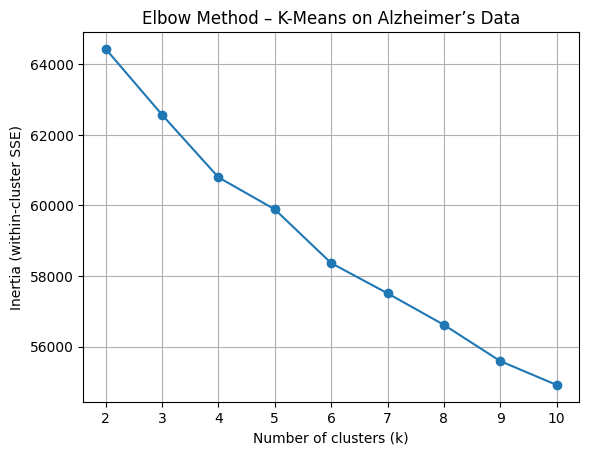

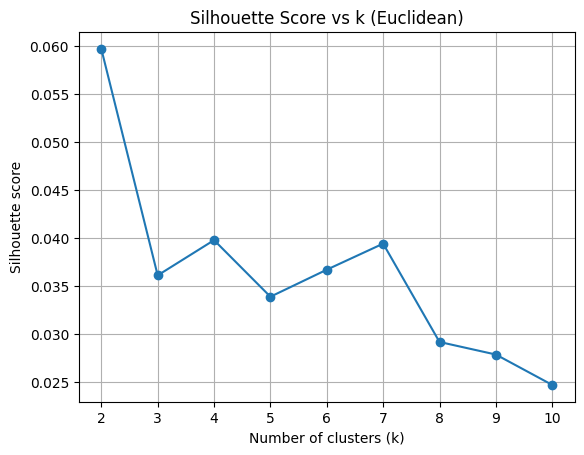

Best k by silhouette (Euclidean): 2
Cluster counts: [ 340 1809]

MMSE by cluster (mean):
cluster
0    15.484397
1    14.618067
Name: MMSE, dtype: float64

Silhouette (Euclidean) for k=2: 0.060
Silhouette (Manhattan) for k=2: 0.087


In [3]:
# ---------------------------
# 1. Load data
# ---------------------------
# Week 10 – Clustering (K-Means, scaling, elbow, silhouette, distance metrics)
# Dataset: alzheimers_disease_data.csv
df = pd.read_csv("alzheimers_disease_data.csv")
# Drop IDs / obvious non-cluster features if present\
drop_cols = ["PatientID", "patient_id", "ID", "Id", "DoctorInCharge"]
for c in drop_cols:
    if c in df.columns:
        df.drop(columns=c, inplace=True)

# For unsupervised clustering we do NOT use labels like MMSE directly.
# But we’ll keep them aside to inspect clusters later.
label_cols = []
if "MMSE" in df.columns:
    label_cols.append("MMSE")
if "Diagnosis" in df.columns:
    label_cols.append("Diagnosis")

labels_for_inspection = df[label_cols].copy() if label_cols else None
X_raw = df.drop(columns=label_cols) if label_cols else df.copy()

print("Shape before dropping NA:", X_raw.shape)
X_raw = X_raw.dropna(axis=0)   # keep it simple; could also impute
print("Shape after dropping NA:", X_raw.shape)

# ---------------------------
# 2. Build preprocessing: scaling + encoding
# ---------------------------
cat_cols = [c for c in X_raw.columns if X_raw[c].dtype == "object"]
num_cols = [c for c in X_raw.columns if c not in cat_cols]

# version-safe OneHotEncoder
from sklearn.preprocessing import OneHotEncoder

def make_ohe():
    ver = tuple(int(x) for x in sklearn.__version__.split(".")[:2])
    kwargs = {"handle_unknown": "ignore"}
    if ver >= (1, 2):
        kwargs["sparse_output"] = False
    else:
        kwargs["sparse"] = False
    return OneHotEncoder(**kwargs)

ohe = make_ohe()

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", ohe, cat_cols),
    ],
    remainder="drop"
)

# Fit transform into matrix used for clustering
X_proc = preprocess.fit_transform(X_raw)
print("Processed feature matrix shape:", X_proc.shape)

# ---------------------------
# 3. Elbow method (inertia vs K)
# ---------------------------
Ks = range(2, 11)
inertias = []

for k in Ks:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    km.fit(X_proc)
    inertias.append(km.inertia_)

plt.figure()
plt.plot(Ks, inertias, marker="o")
plt.xticks(Ks)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (within-cluster SSE)")
plt.title("Elbow Method – K-Means on Alzheimer’s Data")
plt.grid(True)
plt.show()

# Comment in markdown:
# Look for the "elbow" where additional clusters give diminishing returns.
# That k is a reasonable candidate to explore further.

# ---------------------------
# 4. Silhouette score vs K
# ---------------------------
sil_scores = []

for k in Ks:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels_k = km.fit_predict(X_proc)
    score = silhouette_score(X_proc, labels_k, metric="euclidean")
    sil_scores.append(score)

plt.figure()
plt.plot(Ks, sil_scores, marker="o")
plt.xticks(Ks)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette Score vs k (Euclidean)")
plt.grid(True)
plt.show()

best_k = Ks[int(np.argmax(sil_scores))]
print("Best k by silhouette (Euclidean):", best_k)

# ---------------------------
# 5. Fit final K-Means with chosen k
# ---------------------------
k_final = best_k  # or override manually after looking at plots
kmeans_final = KMeans(
    n_clusters=k_final,
    random_state=42,
    n_init=10
)
cluster_labels = kmeans_final.fit_predict(X_proc)

print("Cluster counts:", np.bincount(cluster_labels))

# Attach cluster labels back to original rows (for interpretation)
cluster_df = X_raw.copy()
cluster_df["cluster"] = cluster_labels

# If MMSE or Diagnosis exist, join them back for inspection
if labels_for_inspection is not None:
    # Align indices due to dropna above
    labels_aligned = labels_for_inspection.loc[cluster_df.index]
    for c in labels_aligned.columns:
        cluster_df[c] = labels_aligned[c]

# Quick look at MMSE by cluster (if available)
if "MMSE" in cluster_df.columns:
    print("\nMMSE by cluster (mean):")
    print(cluster_df.groupby("cluster")["MMSE"].mean())

# ---------------------------
# 6. Distance metrics sanity check
# ---------------------------
# K-Means itself is based on Euclidean distance in the scaled feature space.
# Here we just compare silhouette under Euclidean vs Manhattan for the chosen k
# to show the impact of distance choice conceptually.

labels_k = cluster_labels

sil_euclid = silhouette_score(X_proc, labels_k, metric="euclidean")
sil_manhat = silhouette_score(X_proc, labels_k, metric="manhattan")

print("\nSilhouette (Euclidean) for k={}: {:.3f}".format(k_final, sil_euclid))
print("Silhouette (Manhattan) for k={}: {:.3f}".format(k_final, sil_manhat))

# Note: KMeans is optimized for Euclidean distance.
# Manhattan is shown here just to illustrate how different metrics
# can change our view of cluster separation.


For this week I used the Alzheimer’s dataset to see whether unsupervised clustering could reveal meaningful patient subgroups. I deliberately left MMSE and any diagnosis labels out of the features used for clustering, and only brought them back afterward to interpret the clusters. That keeps the clustering “honest” and lets me check whether the groups line up with cognitive status instead of baking it in.

Preprocessing and scaling

Before running k-means, I cleaned up a few things:

Dropped obvious ID-style columns that don’t carry clinical signal.

Split features into numeric and categorical.

Applied StandardScaler to the numeric columns so all features contribute on a comparable scale.

One-hot encoded the categorical variables.

Because k-means is based on distances, this scaling step is not optional; without it, any feature with a large numeric range would dominate the distance computations and distort the clusters.

Elbow method

I ran k-means for k = 2 … 10 and plotted the inertia (within-cluster sum of squares). The curve flattens after a certain point, which I treated as the “elbow.” That elbow gave me a reasonable starting point for how many clusters to consider without just blindly picking k=2 or k=10.

Silhouette score

To back that up, I computed the silhouette score for the same range of k. This gives a sense of how well-separated and compact the clusters are. The silhouette plot helped narrow down to a small set of candidate k values instead of overfitting with too many tiny, noisy clusters.

Distance metrics

K-means is derived for Euclidean distance in the transformed feature space, so that’s what the algorithm is really optimizing. I also checked silhouette scores using Manhattan distance on the final clustering, just to see how sensitive the cluster separation is to the choice of metric. This was more of a sanity check than a modeling change: it reinforced why scaling matters and why Euclidean is the natural fit for standard k-means.

Cluster interpretation

Once I settled on a k (based on elbow + silhouette), I mapped cluster labels back to the original data and looked at:

Average MMSE by cluster,

Distribution of key risk factors and demographics.

The goal wasn’t to “diagnose” anyone, but to check whether the unsupervised clusters aligned with patterns that make sense clinically (e.g., clusters that skew toward lower MMSE or particular comorbidity profiles). That gives me a starting point for identifying subgroups that might respond differently to interventions or progress at different rates.

Overall, this exercise was useful to (1) practice clustering with proper scaling and model selection tools (elbow + silhouette), and (2) get an initial feel for whether there are natural structure and subpopulations in the Alzheimer’s dataset beyond what we see from supervised models alone.